# 08. SHAP Feature Importance 분석
- X구간: pitch15 고정
- Y: whiff% (헛스윙률)
- 목적: 절대값 feature vs delta feature 중 어떤 게 모델에 더 중요한지 확인
- 04_modeling은 wOBA 기준이었으므로 whiff% 기준으로 재분석

---

## 실험 결과 요약

**Val R²: 0.0824 (XGBoost, pitch15, seed=42)**

### feature 유형별 SHAP 중요도

| 유형 | 평균 SHAP | 최고 순위 |
|---|---|---|
| avg (절대값) | 0.00149 | **1위** |
| other (비율 등) | 0.00091 | 4위 |
| prev (기준값) | 0.00060 | 3위 |
| std (절대값) | 0.00041 | 24위 |
| **delta** | **0.00023** | **27위** |

### 상위 feature

| 순위 | feature | 유형 |
|---|---|---|
| 1 | avg_speed_Fastball | avg (절대값) |
| 2 | avg_spin_Fastball | avg (절대값) |
| 3 | prev_spin_Fastball | prev (기준값) |
| 4 | strike_ratio | other |
| 5 | prev_speed_Fastball | prev (기준값) |
| 27 | delta_ext_Fastball | **delta** (최초 등장) |

### Delta feature 상위 5개

| 순위 | feature | SHAP |
|---|---|---|
| 27 | delta_ext_Fastball | 0.000431 |
| 32 | delta_spin_Breaking | 0.000393 |
| 33 | delta_pos_x_Fastball | 0.000356 |
| 42 | delta_spin_Fastball | 0.000274 |
| 43 | delta_pos_z_Fastball | 0.000273 |

### 결론
- **avg_speed_Fastball, avg_spin_Fastball** 이 압도적 1, 2위 → 모델이 선수 스타일(절대값)을 주로 학습 중
- delta feature는 paired t-test에서 유의미(p=0.017)했지만 SHAP 순위는 하위권 (최고 27위)
- delta는 소폭 기여하지만 절대값의 영향력이 훨씬 큼
- **→ biomechanical feature 추가의 필요성 시사**: 순수한 컨디션 state 예측을 위해선 영상 기반 데이터가 핵심

In [1]:
# ── 환경 감지 ──────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
    NB_DIR = os.path.join(DRIVE, '3_modeling')
    sys.path.insert(0, NB_DIR)
else:
    DRIVE  = os.path.dirname(os.path.abspath('__file__'))
    NB_DIR = os.path.dirname(os.path.abspath('__file__'))

FEATURE_DIR = os.path.join(DRIVE, '0_data', '4_features')
OUTPUT_DIR  = os.path.join(DRIVE, '4_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEAT_PATH = os.path.join(FEATURE_DIR, 'features_pitch15.parquet')

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'데이터: {FEAT_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경: 코랩
데이터: /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_pitch15.parquet


In [2]:
# ── 패키지 ─────────────────────────────────────────────────
try:
    import xgboost, shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', 'shap', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'XGBoost: {xgb.__version__}')
print(f'SHAP   : {shap.__version__}')

XGBoost: 3.2.0
SHAP   : 0.51.0


## 1. 데이터 로드 및 학습

In [3]:
df = pd.read_parquet(FEAT_PATH)

META_COLS    = ['game_pk', 'pitcher', 'season', 'y_whiff', 'swings']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

train = df[df['season'].isin([2021, 2022, 2023])]
val   = df[df['season'] == 2024]

X_train, y_train = train[FEATURE_COLS], train['y_whiff']
X_val,   y_val   = val[FEATURE_COLS],   val['y_whiff']

print(f'Train: {len(train):,}행  |  Val: {len(val):,}행')
print(f'Feature 수: {len(FEATURE_COLS)}')

Train: 13,871행  |  Val: 4,668행
Feature 수: 59


In [4]:
model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0,
    early_stopping_rounds=50,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_r2 = r2_score(y_val, model.predict(X_val))
print(f'Val R²: {val_r2:.4f}')
print(f'Best iteration: {model.best_iteration}')

Val R²: 0.0824
Best iteration: 43


## 2. SHAP 계산

In [5]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_val)
print('SHAP 계산 완료')

SHAP 계산 완료


## 3. 전체 Feature Importance (Bar)

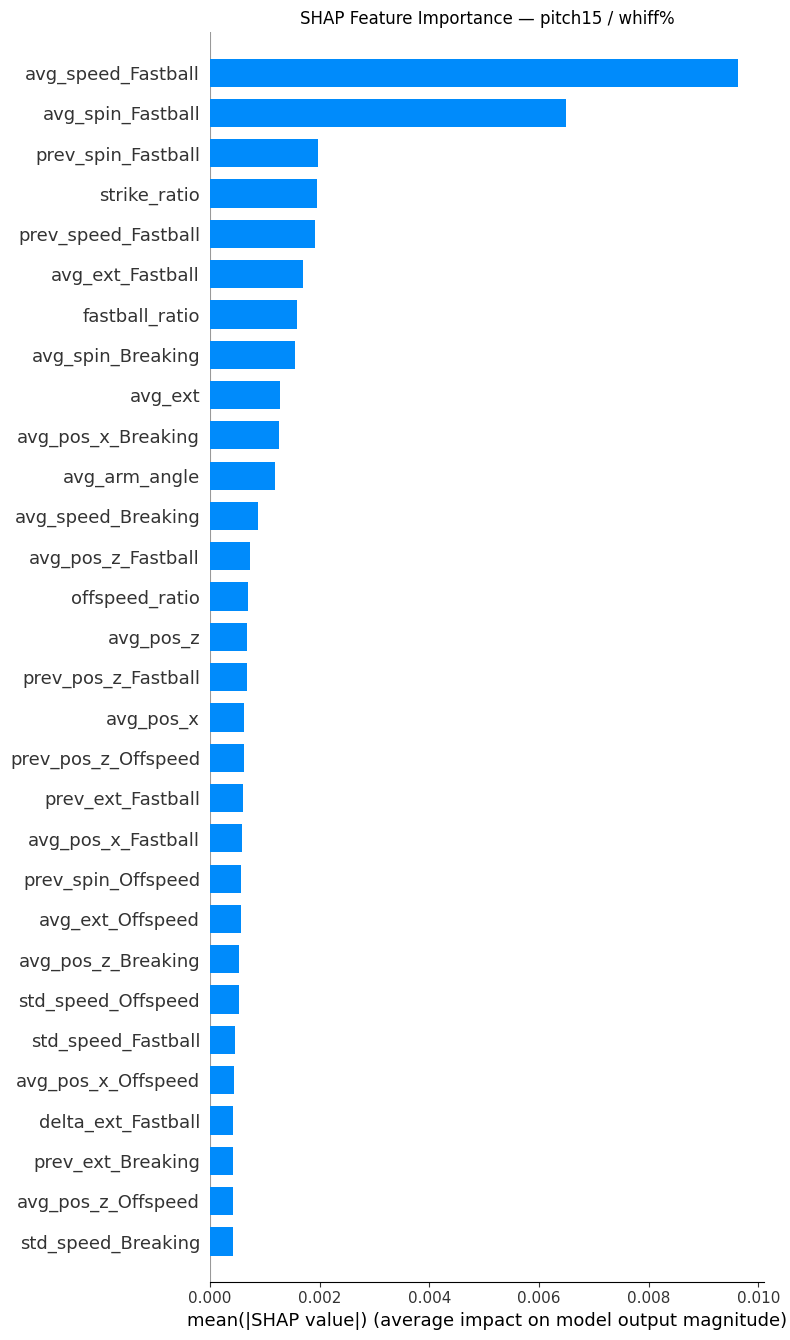

저장 완료


In [6]:
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_val, plot_type='bar', show=False, max_display=30)
plt.title('SHAP Feature Importance — pitch15 / whiff%')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_bar_pitch15.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료')

## 4. Beeswarm Plot (방향성 확인)

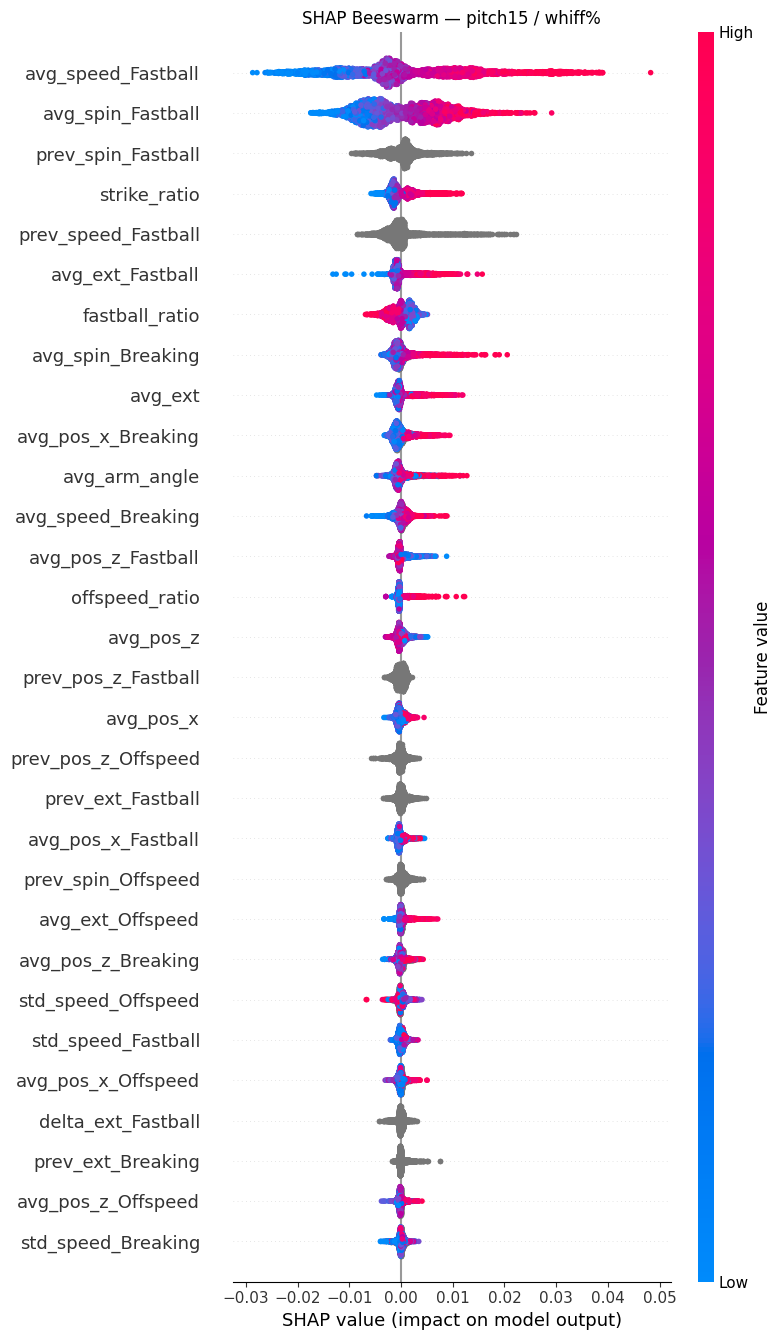

In [7]:
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_val, show=False, max_display=30)
plt.title('SHAP Beeswarm — pitch15 / whiff%')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_beeswarm_pitch15.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. 절대값 vs Delta feature 순위 비교

In [8]:
# feature별 평균 |SHAP| 계산
shap_mean = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'mean_shap':  np.abs(shap_values.values).mean(axis=0),
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

shap_mean['rank'] = shap_mean.index + 1

# feature 유형 분류
def classify(feat):
    if feat.startswith('delta_'):   return 'delta'
    if feat.startswith('prev_'):    return 'prev (기준값)'
    if feat.startswith('avg_'):     return 'avg (절대값)'
    if feat.startswith('std_'):     return 'std (절대값)'
    return 'other'

shap_mean['type'] = shap_mean['feature'].apply(classify)

# 유형별 요약
type_summary = shap_mean.groupby('type').agg(
    count      = ('feature', 'count'),
    mean_shap  = ('mean_shap', 'mean'),
    top_rank   = ('rank', 'min'),
).sort_values('mean_shap', ascending=False)

print('=== feature 유형별 SHAP 요약 ===')
print(type_summary.round(5).to_string())
print()
print('=== 상위 20개 feature ===')
print(shap_mean[['rank', 'feature', 'type', 'mean_shap']].head(20).to_string(index=False))

=== feature 유형별 SHAP 요약 ===
            count  mean_shap  top_rank
type                                  
avg (절대값)      20    0.00149         1
other           5    0.00091         4
prev (기준값)     15    0.00060         3
std (절대값)       4    0.00041        24
delta          15    0.00023        27

=== 상위 20개 feature ===
 rank             feature       type  mean_shap
    1  avg_speed_Fastball  avg (절대값)   0.009627
    2   avg_spin_Fastball  avg (절대값)   0.006487
    3  prev_spin_Fastball prev (기준값)   0.001971
    4        strike_ratio      other   0.001946
    5 prev_speed_Fastball prev (기준값)   0.001925
    6    avg_ext_Fastball  avg (절대값)   0.001699
    7      fastball_ratio      other   0.001591
    8   avg_spin_Breaking  avg (절대값)   0.001547
    9             avg_ext  avg (절대값)   0.001282
   10  avg_pos_x_Breaking  avg (절대값)   0.001254
   11       avg_arm_angle  avg (절대값)   0.001184
   12  avg_speed_Breaking  avg (절대값)   0.000883
   13  avg_pos_z_Fastball  avg (절대값)   0.000728
   

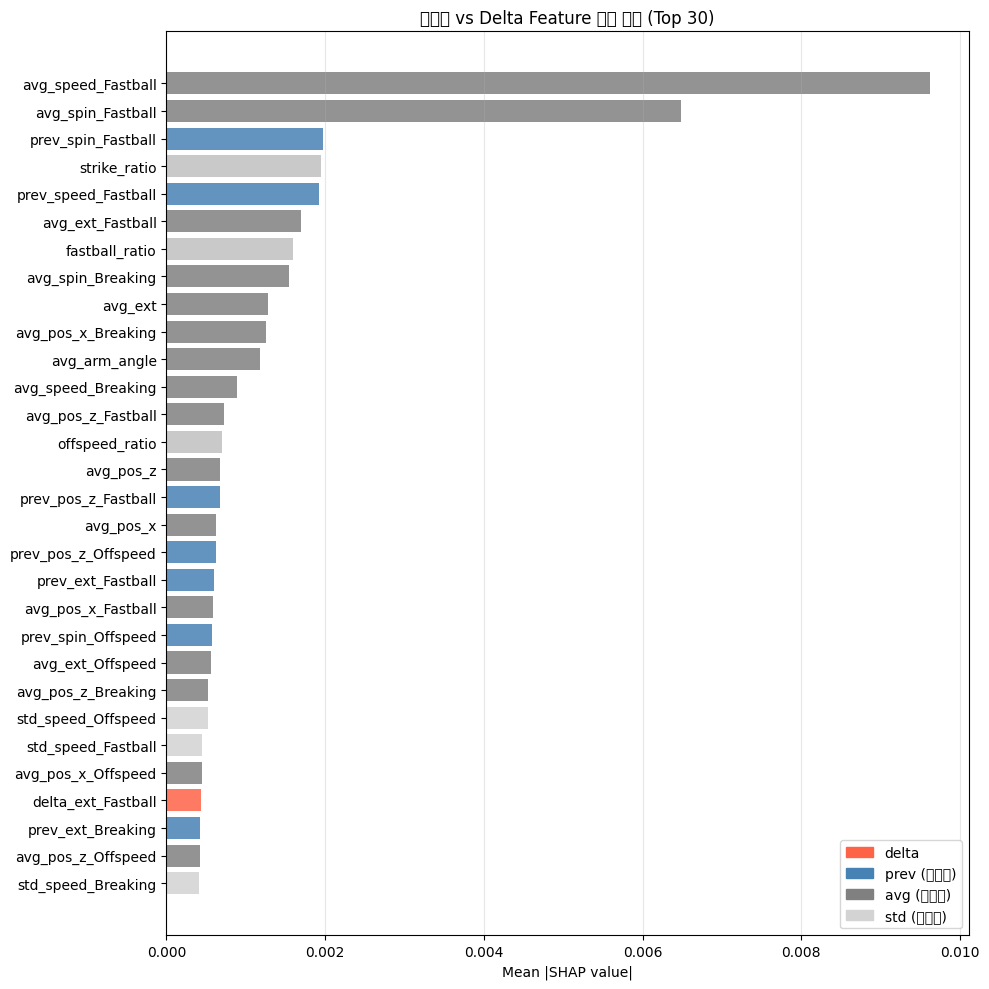

In [9]:
# 유형별 색상으로 상위 30개 시각화
color_map = {
    'delta':       'tomato',
    'prev (기준값)': 'steelblue',
    'avg (절대값)':  'gray',
    'std (절대값)':  'lightgray',
    'other':       'silver',
}

top30 = shap_mean.head(30)
colors = top30['type'].map(color_map)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(top30['feature'][::-1], top30['mean_shap'][::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('절대값 vs Delta Feature 순위 비교 (Top 30)')

# 범례
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in color_map.items() if k != 'other']
ax.legend(handles=legend, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_type_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. 결과 저장

In [10]:
out = os.path.join(OUTPUT_DIR, 'shap_feature_importance.csv')
shap_mean.to_csv(out, index=False)
print(f'저장 완료 → {out}')
print()
print('=== delta feature가 상위권인지 확인 ===')
delta_ranks = shap_mean[shap_mean['type'] == 'delta'][['rank', 'feature', 'mean_shap']].head(5)
avg_ranks   = shap_mean[shap_mean['type'] == 'avg (절대값)'][['rank', 'feature', 'mean_shap']].head(5)
print('\n[Delta top5]')
print(delta_ranks.to_string(index=False))
print('\n[Avg top5]')
print(avg_ranks.to_string(index=False))

저장 완료 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/shap_feature_importance.csv

=== delta feature가 상위권인지 확인 ===

[Delta top5]
 rank              feature  mean_shap
   27   delta_ext_Fastball   0.000431
   32  delta_spin_Breaking   0.000393
   33 delta_pos_x_Fastball   0.000356
   42  delta_spin_Fastball   0.000274
   43 delta_pos_z_Fastball   0.000273

[Avg top5]
 rank            feature  mean_shap
    1 avg_speed_Fastball   0.009627
    2  avg_spin_Fastball   0.006487
    6   avg_ext_Fastball   0.001699
    8  avg_spin_Breaking   0.001547
    9            avg_ext   0.001282
